In [19]:
from PIL import Image

In [23]:
image = Image.open("C:\\Users\\acer\\mario.png")
image.show()

In [21]:
print("Image Format :", image.format)
print("Image Size :", image.size)
print("Image Mode :", image.mode)

Image Format : PNG
Image Size : (1200, 1098)
Image Mode : RGBA


In [1]:
from PIL import Image

# Load image
image_colored = Image.open("C:/Users/acer/mario.png")

# Get width and height
width, height = image_colored.size

# Get channels (RGB = 3)
channels = len(image_colored.getbands())

# Print shape
print(f"Image shape (RGB): ({height}, {width}, {channels})")

# Calculate total size
image_size_colored = width * height * channels
print(f"Image size (RGB): {image_size_colored}")

Image shape (RGB): (1098, 1200, 4)
Image size (RGB): 5270400


In [5]:
import numpy as np
image_array_colored = np . array ( image_colored )
# Display the shape of the NumPy array (height , width ,channels )
print (" Shape of the image array :", image_array_colored .shape )


 Shape of the image array : (1098, 1200, 4)


In [6]:
# Convert the Pillow image to a NumPy array
image_array_colored = np . array ( image_colored )
# Display the shape of the NumPy array (height , width ,channels )
print (" Shape of the image array :", image_array_colored . shape)
#For Red Channels
red_channel = image_array_colored [: , : , 0] # Red channel
print ( red_channel )
display ( red_channel )
# For Green Channels
green_channel = image_array_colored [: , : , 0] # Greenchannel
print ( green_channel )
display ( green_channel )

 Shape of the image array : (1098, 1200, 4)
[[128 128 128 ... 255 255 255]
 [128 128 128 ... 255 255 255]
 [128 128 128 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


array([[128, 128, 128, ..., 255, 255, 255],
       [128, 128, 128, ..., 255, 255, 255],
       [128, 128, 128, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1098, 1200), dtype=uint8)

[[128 128 128 ... 255 255 255]
 [128 128 128 ... 255 255 255]
 [128 128 128 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


array([[128, 128, 128, ..., 255, 255, 255],
       [128, 128, 128, ..., 255, 255, 255],
       [128, 128, 128, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1098, 1200), dtype=uint8)

In [7]:
# For Blue Channel :
blue_channel = image_array_colored [: , : , 2] # Blue channel
print ( blue_channel )
display ( blue_channel )

[[189 189 189 ... 255 255 255]
 [189 189 189 ... 255 255 255]
 [189 189 189 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]


array([[189, 189, 189, ..., 255, 255, 255],
       [189, 189, 189, ..., 255, 255, 255],
       [189, 189, 189, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1098, 1200), dtype=uint8)

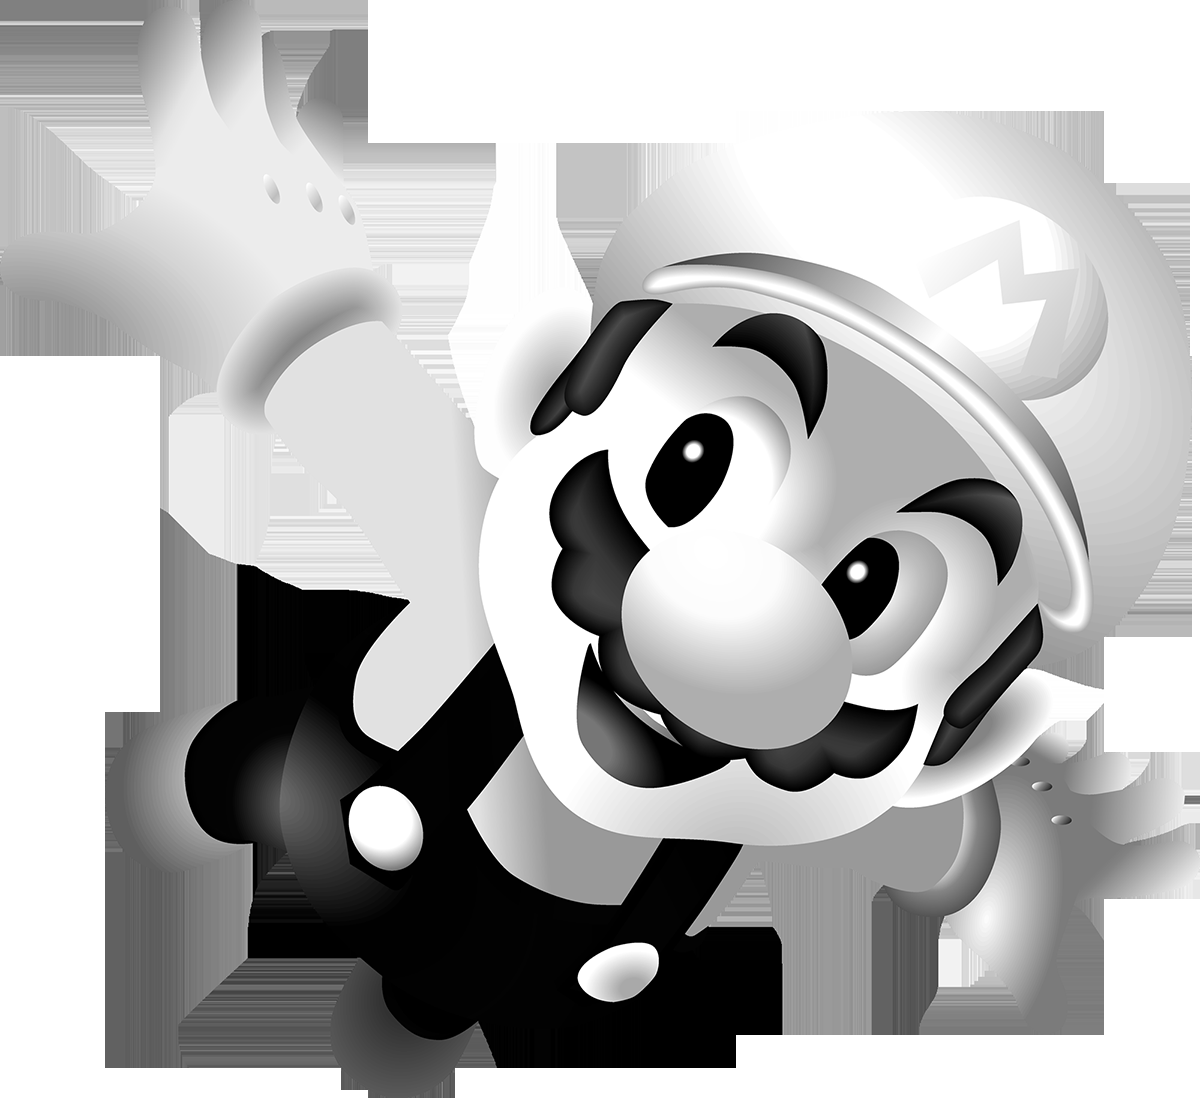

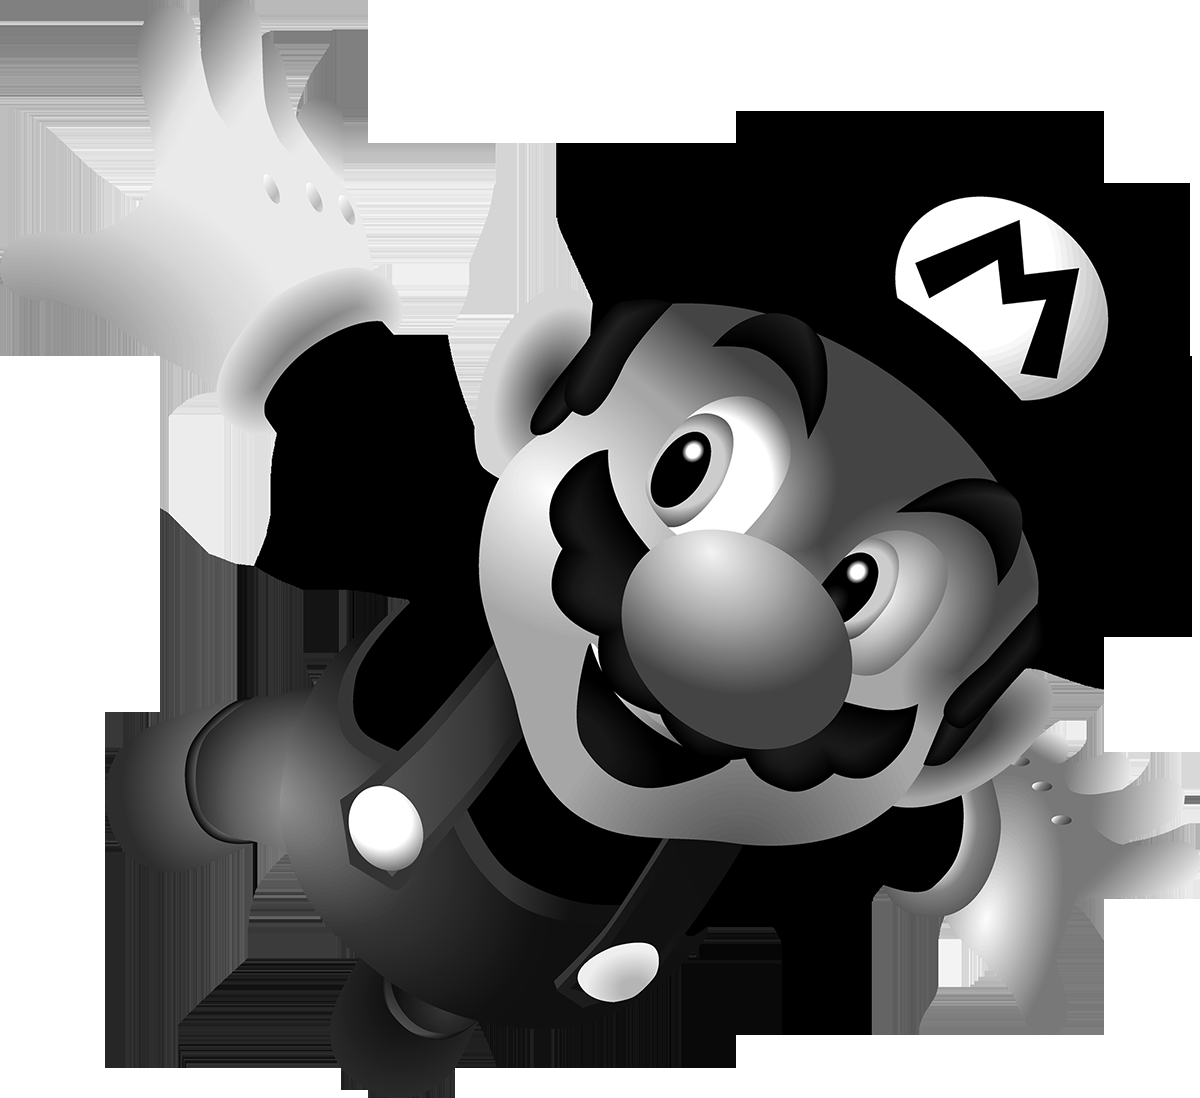

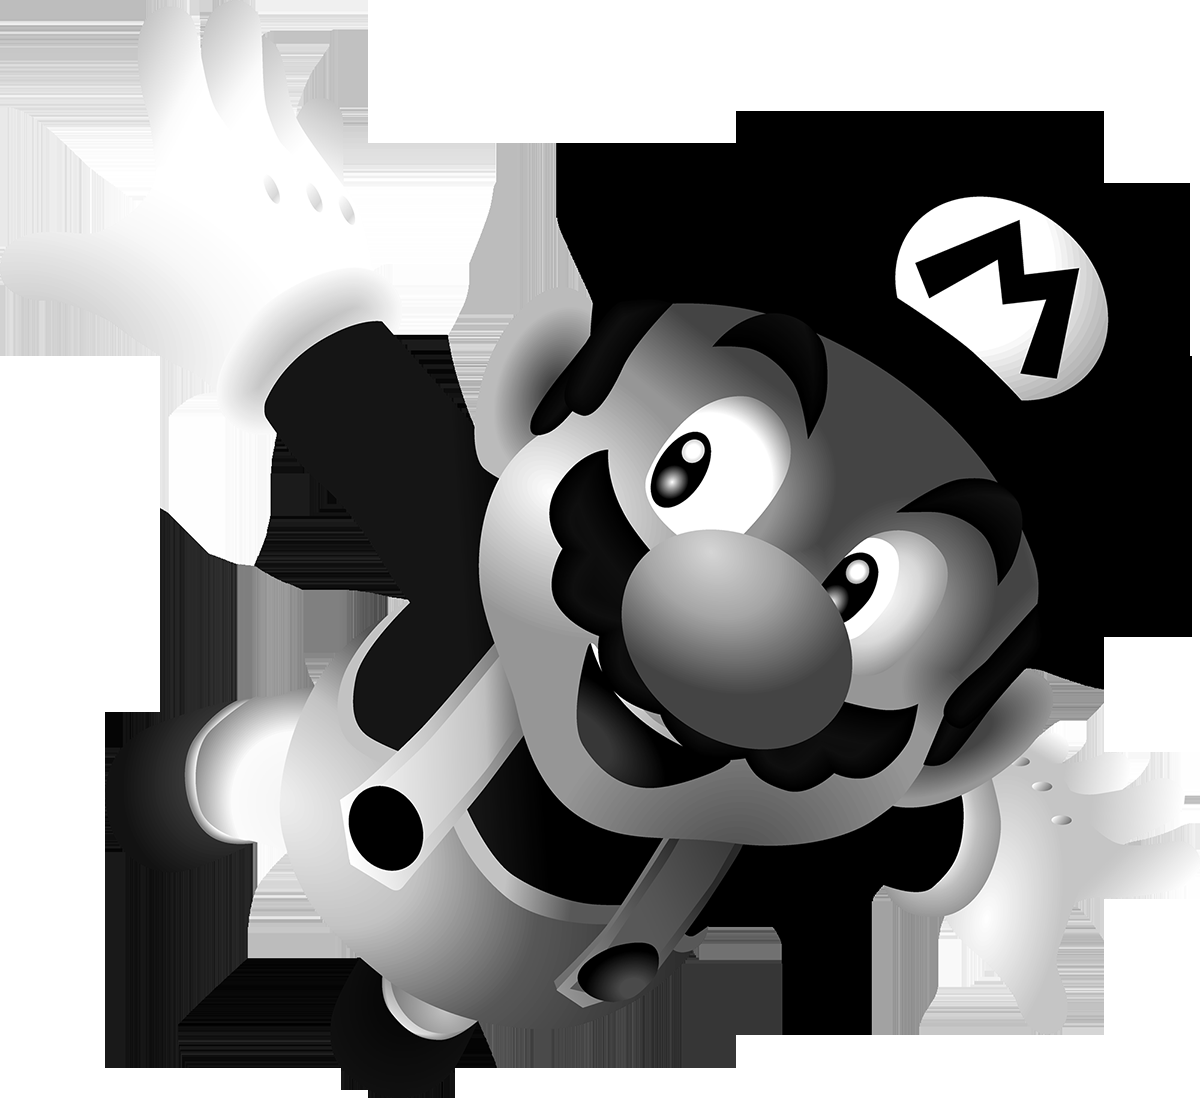

In [10]:
# Assuming image_colored is already defined and loaded above
# Get the R, G, and B channels
r , g , b , a= image_colored . split ()
display ( r )
display ( g )
display ( b )

In [12]:
# Sample Implementation:

# Accessing a specific row - 100th row
row_100 = image_array_colored[100, :, :]

# Accessing a specific column - 50th column
col_50 = image_array_colored[:, 50, :]

# Accessing a specific pixel (row 10, col 20)
pixel = image_array_colored[10, 20, :]  # Gets RGB values at (10, 20)

# Display results
print("100th row shape:", row_100.shape)
print("50th column shape:", col_50.shape)
print("Pixel at (10,20):", pixel)

100th row shape: (1200, 4)
50th column shape: (1098, 4)
Pixel at (10,20): [128 128 189   0]


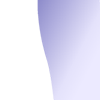

In [14]:
# Define the cropping box (left , upper , right , lower )
left = 100  
upper = 50  
right = 200 
lower = 150
# Crop the image
cropped_image = image_colored . crop (( left , upper , right ,lower ) )
# Display the cropped image
display ( cropped_image )

In [16]:
# Create a NumPy array (dummy image for illustration)
image_array = np.zeros((100, 100, 3), dtype=np.uint8)  # Black image

# Convert the NumPy array back to a Pillow Image object
image_from_array = Image.fromarray(image_array)

# Display the image
image_from_array.show()

# Optionally save the image to a file
image_from_array.save("output_image.jpg")

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
# Load image and convert to grayscale
image = Image.open("C:\\Users\\acer\\mario.png"). convert ("L")
# Convert to NumPy array
image_array = np . array ( image )
# Get image dimensions
height , width = image_array . shape
# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array . reshape ( height , width )

In [26]:
# Compute the mean of each column ( feature )
mean = np . mean ( data , axis =0)
# Subtract mean to center the data
centered_data = data - mean

In [27]:
# Compute covariance matrix
cov_matrix = np . cov ( centered_data , rowvar = False )

In [28]:
# Compute eigenvalues and eigenvectors
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

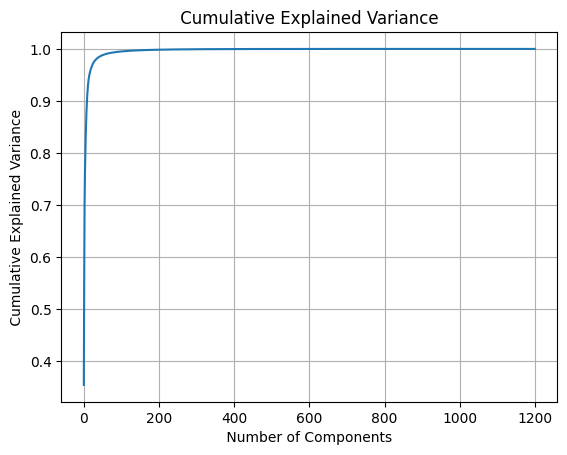

In [29]:
1 # Plot the explained variance ratio
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

In [30]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

In [31]:
# Project the data onto the principal components
compressed_data = np . dot ( centered_data , components )

In [32]:
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T ) + mean

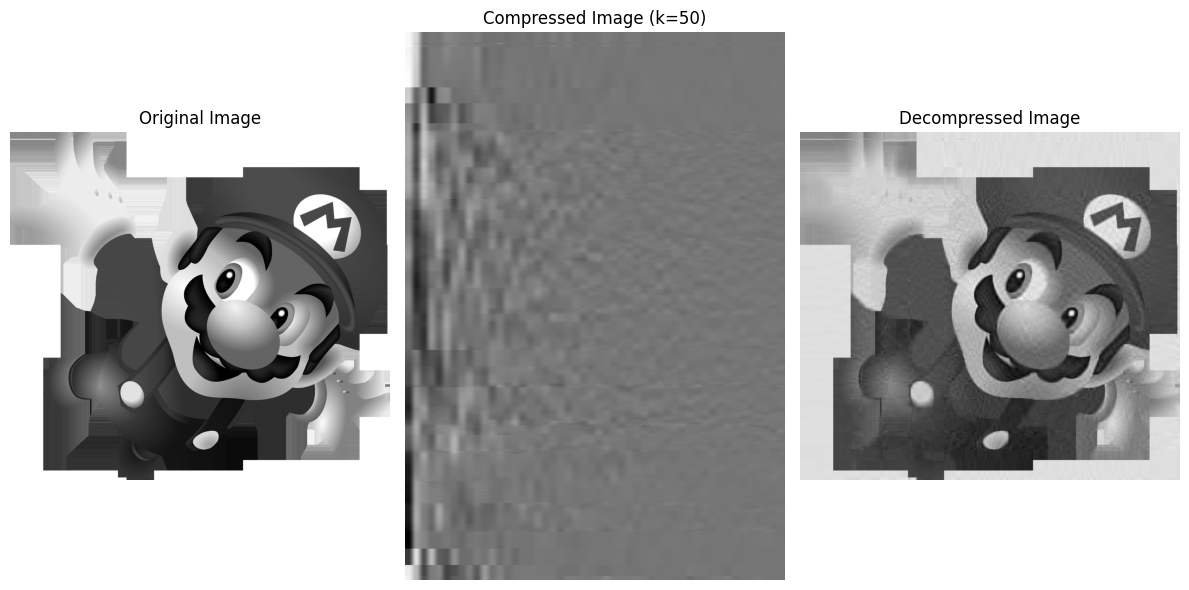

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# Original Image
plt.subplot(1, 3, 1)
plt.imshow(image_array, cmap="gray")  # remove spaces
plt.title("Original Image")
plt.axis("off")

# Compressed Representation
plt.subplot(1, 3, 2)
plt.imshow(compressed_data, cmap="gray", aspect="auto")  # remove spaces
plt.title(f"Compressed Image (k={k})")
plt.axis("off")

# Decompressed Image
plt.subplot(1, 3, 3)
plt.imshow(decompressed_data, cmap="gray")  # remove spaces
plt.title("Decompressed Image")
plt.axis("off")

plt.tight_layout()
plt.show()